In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import os
import cv2
import numpy as np
import time
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torchsummary import summary
import pickle

In [2]:
# Bước 2: Configuration
DATA_PATH = "/kaggle/input/data-culilam/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_tonghop_tk1"
IMAGE_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 80
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cuda
CUDA available: True


In [3]:
# Bước 3: Data Preprocessing Functions

def brighten_image(img, factor=1.2):
    brightened = cv2.convertScaleAbs(img, alpha=factor, beta=0)
    return brightened

def enhance_contrast(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return enhanced

def sharpen_image(img, strength=0.5):
    kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]]) # Sửa lại kernel để phù hợp
    sharpened = cv2.filter2D(img, -1, kernel) # Dùng -1 cho depth để output cùng depth với input
    # Trộn ảnh gốc và ảnh sắc nét
    result = cv2.addWeighted(img, 1.0 - strength, sharpened, strength, 0)
    return result

def process_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = brighten_image(img)
    img = enhance_contrast(img)
    img = sharpen_image(img)
    img = cv2.resize(img, target_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def split_dataset_stratified(data_dir, test_size=0.2, val_size=0.1, random_state=100):
    file_paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    file_paths.append(os.path.join(class_dir, file_name))
                    labels.append(class_idx)
    
    # Chia test
    X_temp, X_test, y_temp, y_test = train_test_split(
        file_paths, labels, test_size=test_size,
        random_state=random_state, stratify=labels
    )
    
    # Chia train/val
    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted,
        random_state=random_state, stratify=y_temp
    )
    
    return (X_train, X_val, X_test), (y_train, y_val, y_test), class_names

Classes: ['Đốm nâu (Brow Spot)', 'Đạo ôn (Leaf Blast)', 'Cháy lá (Leaf Blight)', 'Bình thường (Normal)']
Number of classes: 4
Train samples: 8279
Validation samples: 1183
Test samples: 2366


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


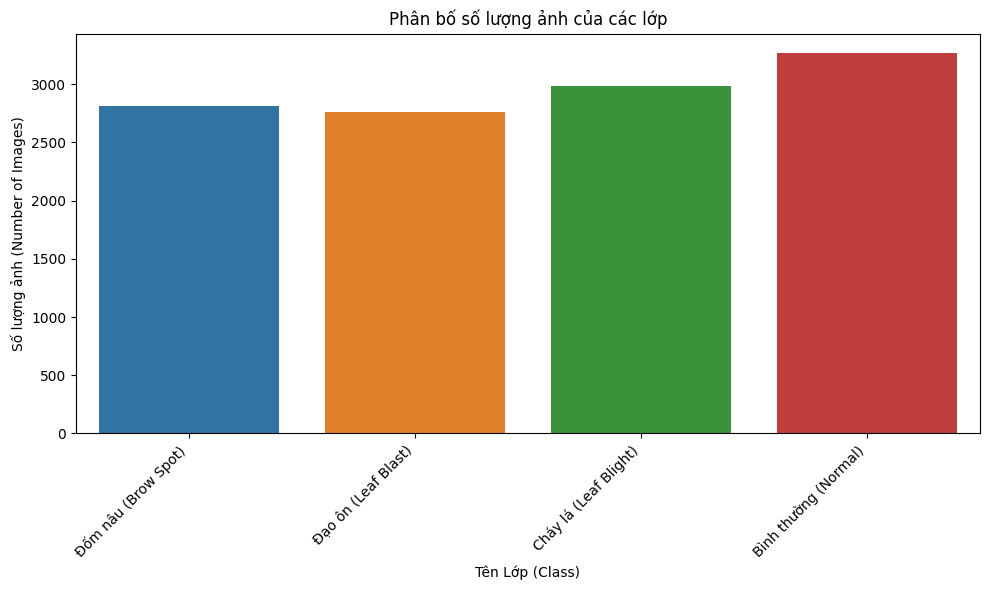

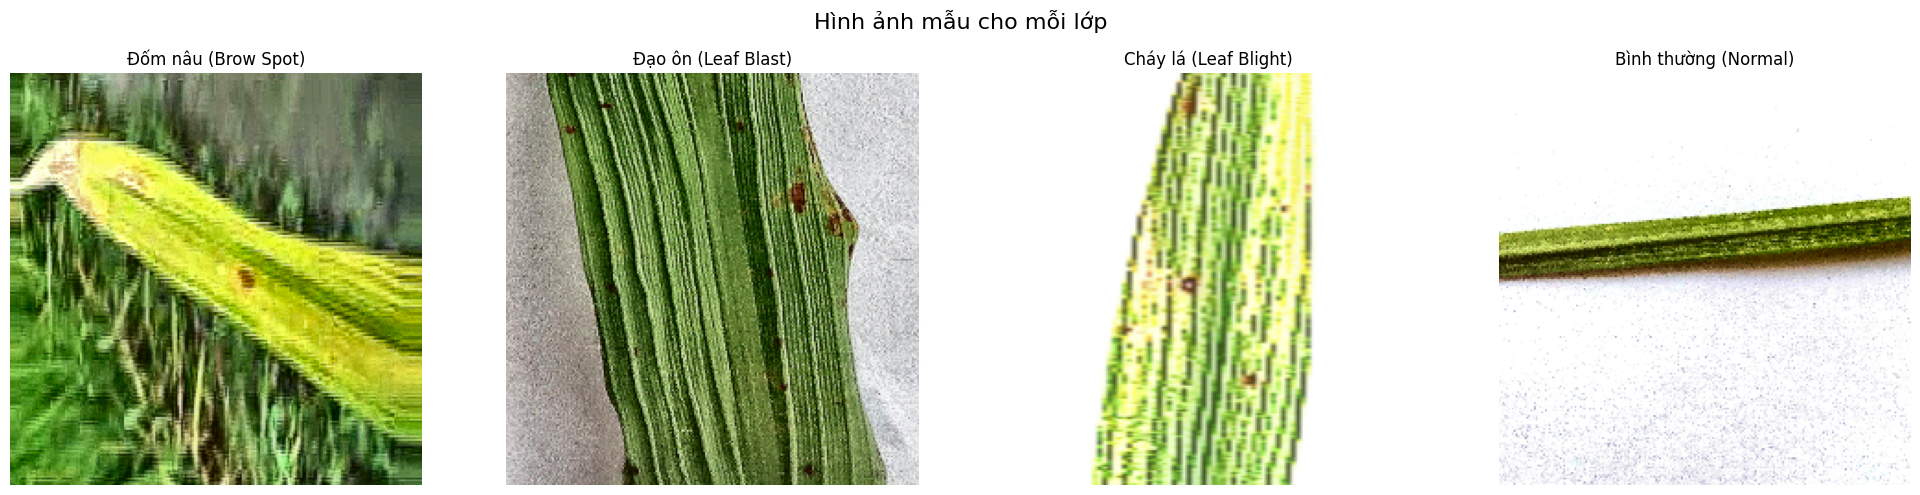

In [4]:
# Bước 4: Load and Split Dataset
(X_train, X_val, X_test), (y_train, y_val, y_test), original_class_names = split_dataset_stratified(DATA_PATH)

class_name_mapping = {
    '01': 'Đốm nâu (Brow Spot)',
    '02': 'Đạo ôn (Leaf Blast)',
    '03': 'Cháy lá (Leaf Blight)',
    '04': 'Bình thường (Normal)'
}

# Ánh xạ tên gốc ('01', '02'...) sang tên đẹp
class_names = [class_name_mapping[name] for name in sorted(original_class_names)]
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# -----------------
# Visualization: Phân bố số lượng ảnh của các lớp
from collections import Counter

all_labels_initial = []
for original_name, pretty_name in zip(original_class_names, class_names):
    # DÙNG TÊN GỐC ('01', '02'...) để tìm thư mục
    class_dir = os.path.join(DATA_PATH, original_name)
    if os.path.isdir(class_dir):
        num_files = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        # DÙNG TÊN ĐẸP (Đốm nâu...) để làm nhãn cho biểu đồ
        all_labels_initial.extend([pretty_name] * num_files)

label_counts = Counter(all_labels_initial)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.title('Phân bố số lượng ảnh của các lớp')
plt.xlabel('Tên Lớp (Class)')
plt.ylabel('Số lượng ảnh (Number of Images)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualization: Hình ảnh mẫu
fig, axes = plt.subplots(1, num_classes, figsize=(20, 5))
fig.suptitle('Hình ảnh mẫu cho mỗi lớp', fontsize=16)

for i, (original_name, pretty_name) in enumerate(zip(original_class_names, class_names)):
    class_dir = os.path.join(DATA_PATH, original_name)
    if os.path.isdir(class_dir) and len(os.listdir(class_dir)) > 0:
        sample_img_name = os.listdir(class_dir)[0]
        img_path = os.path.join(class_dir, sample_img_name)
        img = process_image(img_path)
        
        if img is not None:
            axes[i].imshow(img)
            axes[i].set_title(pretty_name)
            axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [5]:
# Bước 5: PyTorch Dataset Class
class RiceDiseaseDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Sử dụng hàm process_image để đọc, tiền xử lý và resize
        img = process_image(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))

        if img is None:
            # Xử lý trường hợp không đọc được ảnh
            img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)

        # Chuyển từ numpy array/cv2 sang PIL Image để áp dụng transforms
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, label

In [6]:
# Bước 6: Data Transforms and DataLoaders

# Data Transforms
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    # Chuẩn hóa (Normalize)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# train_transform = transforms.Compose([
#     transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(20),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    # Chuẩn hóa (Normalize)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = RiceDiseaseDataset(X_train, y_train, transform=train_transform)
val_dataset = RiceDiseaseDataset(X_val, y_val, transform=train_transform)
test_dataset = RiceDiseaseDataset(X_test, y_test, transform=train_transform)

# BẮT ĐẦU PHẦN CODE CÂN BẰNG DỮ LIỆU
print("\nBắt đầu xử lý cân bằng dữ liệu cho tập train...")
# 1. Đếm số lượng ảnh trong mỗi lớp của tập train
class_counts = np.bincount(y_train)
print(f"Số lượng ảnh mỗi lớp (trước khi cân bằng): {class_counts}")

# 2. Tính toán trọng số (weight) cho mỗi lớp
# Lớp nào càng ít ảnh, trọng số càng cao
class_weights = 1.0 / class_counts
print(f"Trọng số cho mỗi lớp: {class_weights}")

# 3. Tạo một danh sách trọng số cho TỪNG MẪU trong tập train
sample_weights = np.array([class_weights[label] for label in y_train])
sample_weights = torch.from_numpy(sample_weights).double()

# 4. Tạo Sampler (Lấy mẫu ngẫu nhiên có trọng số)
sampler = torch.utils.data.WeightedRandomSampler(
    sample_weights,
    len(sample_weights),
    replacement=True  # Phải là True
)
print("WeightedRandomSampler đã được tạo.")
#--
# DataLoaders
# dl_train dùng sampler và KHÔNG dùng shuffle=True
dl_train = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)

# dl_val và dl_test giữ nguyên, KHÔNG cần cân bằng
dl_val = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
dl_test = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nTrain batches: {len(dl_train)}")
print(f"Validation batches: {len(dl_val)}")
print(f"Test batches: {len(dl_test)}")


Bắt đầu xử lý cân bằng dữ liệu cho tập train...
Số lượng ảnh mỗi lớp (trước khi cân bằng): [1968 1933 2090 2288]
Trọng số cho mỗi lớp: [0.00050813 0.00051733 0.00047847 0.00043706]
WeightedRandomSampler đã được tạo.

Train batches: 130
Validation batches: 19
Test batches: 37


In [7]:
# Helper function to get output channels
def get_channels(module):
    if isinstance(module, nn.Conv2d):
        return module.out_channels
    elif isinstance(module, nn.BatchNorm2d):
        return module.num_features
    elif isinstance(module, (nn.ReLU, nn.Hardswish, nn.LeakyReLU, nn.SELU, nn.Sigmoid, nn.Tanh, nn.Identity)):
        return None  # Skip activations
    elif hasattr(module, 'block') and isinstance(module.block, nn.Module):
        return get_channels(module.block)
    elif isinstance(module, (nn.Sequential, nn.ModuleList)):
        for sub in reversed(list(module.children())):
            ch = get_channels(sub)
            if ch is not None:
                return ch
    elif len(list(module.children())) > 0:
        return get_channels(list(module.children())[-1])
    return None

# Define CBAM (Convolutional Block Attention Module)
class CAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Linear(in_planes, in_planes // ratio, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(in_planes // ratio, in_planes, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu(self.fc1(self.avg_pool(x).squeeze(-1).squeeze(-1))))
        max_out = self.fc2(self.relu(self.fc1(self.max_pool(x).squeeze(-1).squeeze(-1))))
        out = avg_out + max_out
        return self.sigmoid(out).unsqueeze(-1).unsqueeze(-1)

class SAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)

class CBAM_attention(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super().__init__()
        self.ca = CAttention(in_planes, ratio)
        self.sa = SAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# Define Attention Pooling
class AttentionP(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(in_features, in_features // 16),
            nn.ReLU(),
            nn.Linear(in_features // 16, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.size()
        x_flat = x.view(B, C, H * W).permute(0, 2, 1)
        attn = self.attention(x_flat)  # (B, H*W, 1)
        x_weighted = torch.sum(x_flat * attn, dim=1)  # (B, C)
        return x_weighted

# Custom Lightweight Model
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10, weights="DEFAULT"):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights=weights)

        # Modify to add CBAM to last 3 blocks
        features = self.backbone.features
        for i in range(len(features) - 3, len(features)):
            out_channel = get_channels(features[i])
            if out_channel is not None:
                cbam = CBAM_attention(out_channel)
                features[i] = nn.Sequential(features[i], cbam)

        # Replace average pooling with Attention Pooling
        in_features = self.backbone.classifier[0].in_features
        self.pooling = AttentionP(in_features)

        # Classifier
        self.classifier = nn.Linear(in_features, num_classes)

        # For CAM/Grad-CAM: hook last feature map
        self.features = None
        self.backbone.features[-1].register_forward_hook(self._hook_features)

    def _hook_features(self, module, input, output):
        self.features = output

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.pooling(x)
        x = self.classifier(x)
        return x

    # Simplified CAM
    def get_cam(self, x, target_class=None):
        logits = self(x)
        if target_class is None:
            target_class = logits.argmax(dim=1)
        weights = self.classifier.weight[target_class]
        cam = torch.einsum('bc,bchw->bhw', weights, self.features)
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam


model = CustomCNN(num_classes=len(class_names))

# Giữ nguyên phần còn lại
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc = 0.0
save_path = "/content/drive/MyDrive/data/custom_cnn_1_best_model.pth" # Sửa lại thành đường dẫn chung

# print(f"\nModel initialized: CustomCNN (Lightweight)")
# print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
# print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
# summary(model, (3,224,224), device=("cuda" if torch.cuda.is_available() else "cpu"))
# Summary
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# đảm bảo model nằm đúng thiết bị
model = model.to(DEVICE)

# gọi summary với device='cuda' hoặc 'cpu' tương ứng
summary(model, input_size=(3, 224, 224), device=("cuda" if torch.cuda.is_available() else "cpu"))


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 209MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             432
       BatchNorm2d-2         [-1, 16, 112, 112]              32
         Hardswish-3         [-1, 16, 112, 112]               0
            Conv2d-4           [-1, 16, 56, 56]             144
       BatchNorm2d-5           [-1, 16, 56, 56]              32
              ReLU-6           [-1, 16, 56, 56]               0
 AdaptiveAvgPool2d-7             [-1, 16, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             136
              ReLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 16, 1, 1]             144
      Hardsigmoid-11             [-1, 16, 1, 1]               0
SqueezeExcitation-12           [-1, 16, 56, 56]               0
           Conv2d-13           [-1, 16, 56, 56]             256
      BatchNorm2d-14           [-1, 16,

In [8]:
# Bước 8: Training Function
def run_epoch(dataloader, train=True):
    model.train(mode=train)
    epoch_loss, correct, total = 0.0, 0, 0
    
    for images, labels in dataloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)
        
        if train:
            loss.backward()
            optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return epoch_loss / total, correct / total

In [9]:
# Bước 9: Training Loop (Bổ sung Early Stopping)
train_losses, train_accs = [], []
val_losses, val_accs = [], []

# Thông số cho Early Stopping
patience = 5  # Số epoch chờ đợi
epochs_no_improve = 0
best_val_acc = 0.0 # Khởi tạo lại
save_path = "/kaggle/working/custom_cnn_2_best_model.pth" # Đường dẫn lưu model

# print(f"Bắt đầu huấn luyện với Early Stopping (patience={patience})...")

# for epoch in range(1, EPOCHS + 1):
#     t0 = time.time()
    
#     tr_loss, tr_acc = run_epoch(dl_train, train=True)
#     val_loss, val_acc = run_epoch(dl_val, train=False)
    
#     scheduler.step()
    
#     train_losses.append(tr_loss)
#     train_accs.append(tr_acc)
#     val_losses.append(val_loss)
#     val_accs.append(val_acc)
    
#     print(f"[{epoch:02d}/{EPOCHS}] "
#           f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
#           f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
#           f"time={time.time()-t0:.1f}s")
    
#     # Logic Early Stopping
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         epochs_no_improve = 0 # Đặt lại bộ đếm
#         # Lưu mô hình tốt nhất
#         torch.save({
#             "model": model.state_dict(),
#             "classes": class_names
#         }, save_path)
#         print(f" -> Saved new best to {save_path} (val_acc={best_val_acc:.4f})")
#     else:
#         epochs_no_improve += 1
        
#     # Kiểm tra điều kiện dừng sớm
#     if epochs_no_improve == patience:
#         print(f"\n--- Early stopping kích hoạt! Dừng huấn luyện sau {patience} epoch không cải thiện. ---")
#         break


# print(f"Training completed. Best validation accuracy: {best_val_acc:.4f}")

print(f"Bắt đầu huấn luyện với Early Stopping (patience={patience})...")

best_val_loss = float('inf')  # ban đầu gán vô cực để val_loss nhỏ hơn sẽ cập nhật
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    
    tr_loss, tr_acc = run_epoch(dl_train, train=True)
    val_loss, val_acc = run_epoch(dl_val, train=False)
    
    scheduler.step()
    
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"time={time.time()-t0:.1f}s")
    
    #  Logic Early Stopping theo val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0  # đặt lại bộ đếm
        
        # Lưu mô hình tốt nhất
        torch.save({
            "model": model.state_dict(),
            "classes": class_names
        }, save_path)
        print(f" -> Saved new best to {save_path} (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        
    # Kiểm tra điều kiện dừng sớm
    if epochs_no_improve == patience:
        print(f"\n--- Early stopping kích hoạt! Dừng huấn luyện sau {patience} epoch không cải thiện val_loss. ---")
        break

print(f"Training completed. Best validation loss: {best_val_loss:.4f}")


Bắt đầu huấn luyện với Early Stopping (patience=5)...
[01/80] train_loss=0.9421 acc=0.6241 | val_loss=1.3656 acc=0.3263 | time=260.3s
 -> Saved new best to /kaggle/working/custom_cnn_2_best_model.pth (val_loss=1.3656)
[02/80] train_loss=0.4839 acc=0.8116 | val_loss=0.9253 acc=0.7608 | time=253.9s
 -> Saved new best to /kaggle/working/custom_cnn_2_best_model.pth (val_loss=0.9253)
[03/80] train_loss=0.3808 acc=0.8503 | val_loss=0.4231 acc=0.8453 | time=244.0s
 -> Saved new best to /kaggle/working/custom_cnn_2_best_model.pth (val_loss=0.4231)
[04/80] train_loss=0.3184 acc=0.8758 | val_loss=0.3442 acc=0.8639 | time=246.1s
 -> Saved new best to /kaggle/working/custom_cnn_2_best_model.pth (val_loss=0.3442)
[05/80] train_loss=0.2820 acc=0.8926 | val_loss=0.3873 acc=0.8563 | time=249.0s
[06/80] train_loss=0.2493 acc=0.9032 | val_loss=0.3061 acc=0.8867 | time=251.1s
 -> Saved new best to /kaggle/working/custom_cnn_2_best_model.pth (val_loss=0.3061)
[07/80] train_loss=0.2279 acc=0.9092 | val_los

In [10]:
# Bước 10: Evaluation on Test Set (Bổ sung FPS)

# Hàm tính FPS
def calculate_fps(model, dataloader, device, num_warmup=10, num_runs=50):
    model.eval()
    times = []
    
    # Warm-up (chạy vài lần đầu để ổn định)
    for _ in range(num_warmup):
        try:
            images, _ = next(iter(dataloader))
            images = images.to(device)
            _ = model(images)
        except StopIteration:
            break
            
    # Đo thời gian
    with torch.no_grad():
        for _ in range(num_runs):
            try:
                images, _ = next(iter(dataloader))
                images = images.to(device)
                
                start_time = time.time()
                _ = model(images)
                end_time = time.time()
                
                times.append(end_time - start_time)
            except StopIteration:
                # Đảm bảo dataloader đủ lớn
                break

    if not times:
        return 0.0
        
    avg_time_per_batch = np.mean(times)
    images_per_batch = dataloader.batch_size
    fps = images_per_batch / avg_time_per_batch
    return fps

# Tải mô hình tốt nhất
checkpoint = torch.load(save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model'])
model.eval()

# Đánh giá trên tập Test
test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in dl_test:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        preds = logits.argmax(1)
        
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f} %)")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Tính FPS
fps = calculate_fps(model, dl_test, DEVICE)
print(f"FPS (Frames Per Second) trên tập Test: {fps:.2f} FPS")


Test Accuracy: 0.9049 (90.49 %)

Classification Report:
                       precision    recall  f1-score   support

  Đốm nâu (Brow Spot)       0.92      0.93      0.93       562
  Đạo ôn (Leaf Blast)       0.83      0.88      0.85       552
Cháy lá (Leaf Blight)       0.91      0.87      0.89       598
 Bình thường (Normal)       0.96      0.93      0.94       654

             accuracy                           0.90      2366
            macro avg       0.90      0.90      0.90      2366
         weighted avg       0.91      0.90      0.91      2366

FPS (Frames Per Second) trên tập Test: 5976.40 FPS


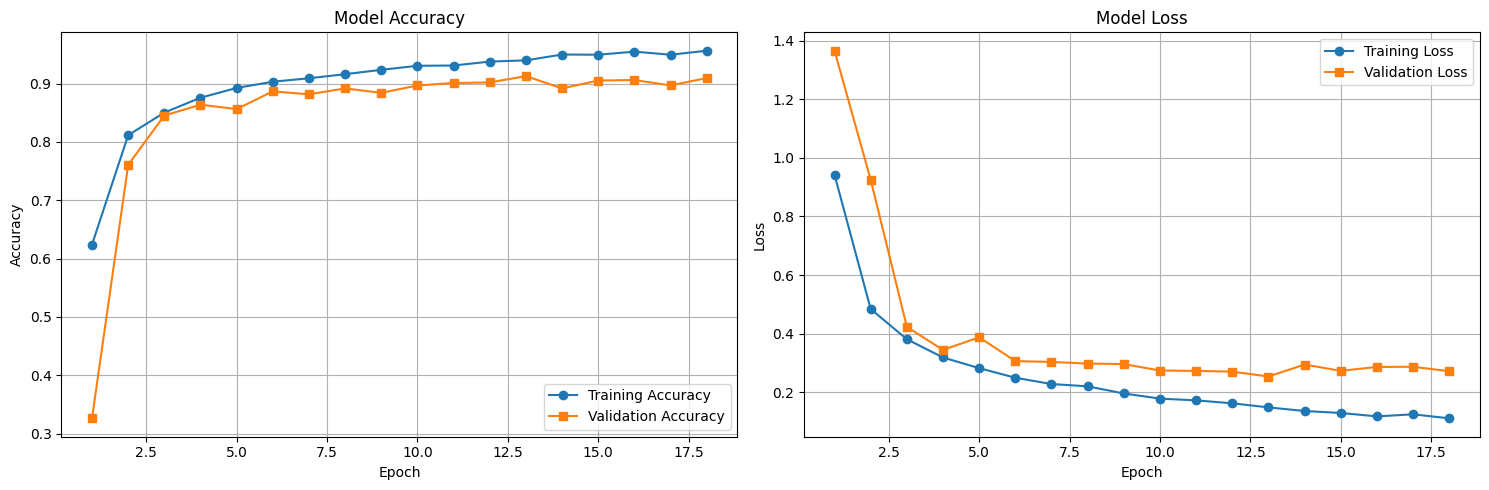

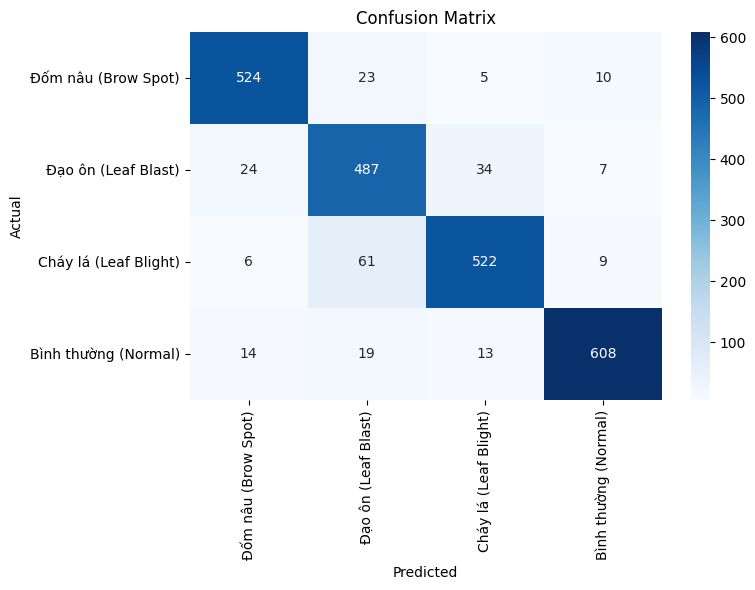


Lịch sử huấn luyện đã được lưu vào: /kaggle/working/custom_cnn_1_training_history.pkl


In [11]:
# Bước 11: Visualization
# --------------------
# 1. Biểu đồ Accuracy và Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(train_accs) + 1)

# Accuracy Plot
ax1.plot(epochs_range, train_accs, label='Training Accuracy', marker='o')
ax1.plot(epochs_range, val_accs, label='Validation Accuracy', marker='s')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(epochs_range, train_losses, label='Training Loss', marker='o')
ax2.plot(epochs_range, val_losses, label='Validation Loss', marker='s')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# --------------------
# 2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


# --------------------
# 3. Lưu lịch sử huấn luyện (Đã sửa lỗi đường dẫn)
training_history = {
    'train_losses': train_losses,
    'train_accs': train_accs,
    'val_losses': val_losses,
    'val_accs': val_accs,
    'epochs_run': len(train_losses)
}

# SỬA LỖI: Dùng đường dẫn tương tự như save_path cho model
history_save_path = "/kaggle/working/custom_cnn_1_training_history.pkl" 

try:
    with open(history_save_path, 'wb') as f:
        pickle.dump(training_history, f)
    print(f"\nLịch sử huấn luyện đã được lưu vào: {history_save_path}")
except FileNotFoundError as e:
    print(f"\n[LỖI LƯU FILE] FileNotFoundError: Kiểm tra lại đường dẫn Google Drive: {e}")

In [12]:
# # Cell 1: Imports - YOU MUST RUN THIS CELL FIRST!
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torchvision.models as models
# import torchvision.transforms as transforms
# from torch.utils.data import Dataset, DataLoader
# import os
# import cv2
# import numpy as np
# import time
# from PIL import Image
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns
# from torchsummary import summary
# import pickle
# # TẢI LẠI MÔ HÌNH TỪ ĐƯỜNG DẪN KAGGLE CỦA BẠN
# KAGGLE_MODEL_PATH = '/kaggle/input/cnn_deep/pytorch/default/1/custom_cnn_2_best_model.pth'

# try:
#     checkpoint = torch.load(KAGGLE_MODEL_PATH, map_location=DEVICE)
#     model.load_state_dict(checkpoint['model'])
    
#     # Đảm bảo mô hình ở chế độ đánh giá
#     model.eval() 
#     print(f"Đã tải mô hình thành công từ: {KAGGLE_MODEL_PATH}")

# except Exception as e:
#     print(f"LỖI TẢI MÔ HÌNH: {e}")
#     exit()

In [13]:
# # HÀM NÀY CẦN PHẢI CHẠY TRƯỚC HÀM evaluate_new_folders
# def predict_image(model, image_path, class_names, device, image_size=224):
#     """
#     Tải ảnh, tiền xử lý, chạy inference và trả về tên lớp dự đoán.
#     """
#     # Bước 1: Tiền xử lý ảnh (sử dụng process_image và val_test_transform)
#     # process_image và val_test_transform phải được định nghĩa từ Cell 4 và Cell 7
#     img_processed_np = process_image(image_path, target_size=(image_size, image_size))
    
#     if img_processed_np is None:
#         print(f"Lỗi: Không thể đọc tệp ảnh tại đường dẫn: {image_path}")
#         return None, None
        
#     img_pil = Image.fromarray(img_processed_np)

#     # Áp dụng validation/test transform
#     # val_test_transform phải được định nghĩa trước đó!
#     img_tensor = val_test_transform(img_pil) 
    
#     # Thêm batch dimension và chuyển lên DEVICE
#     img_input = img_tensor.unsqueeze(0).to(device)

#     # Bước 2: Inference
#     with torch.no_grad():
#         output = model(img_input)
#         probabilities = torch.softmax(output, dim=1)
        
#     # Bước 3: Lấy kết quả dự đoán
#     predicted_prob, predicted_idx = torch.max(probabilities, 1)
    
#     predicted_class_name = class_names[predicted_idx.item()]
    
#     return predicted_class_name, predicted_prob.item()
# # Cell mới: Dự đoán và Đánh giá trên Folder ảnh Test

# # 1. Định nghĩa các folder ảnh test mới
# TEST_FOLDERS = {
#     # Tên lớp THỰC TẾ (Actual Class Name) : Đường dẫn folder
#     "Cháy lá (Leaf Blight)": "/kaggle/input/test-deep/AnhTest/Lá Cháy",
#     "Bình thường (Normal)": "/kaggle/input/test-deep/AnhTest/Lá BT"
# }

# # 2. Hàm dự đoán cho toàn bộ folder
# def evaluate_new_folders(model, test_folders, class_names, device, image_size=224):
#     model.eval()
#     total_correct = 0
#     total_samples = 0
    
#     # Để hiển thị kết quả chi tiết
#     class_results = {}
    
#     print("\n--- Bắt đầu đánh giá trên các folder test mới ---")
    
#     for actual_class_name, folder_path in test_folders.items():
#         correct_in_class = 0
#         total_in_class = 0
        
#         if not os.path.isdir(folder_path):
#             print(f"Cảnh báo: Không tìm thấy thư mục: {folder_path}")
#             continue

#         for file_name in os.listdir(folder_path):
#             if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
#                 img_path = os.path.join(folder_path, file_name)
                
#                 # Chạy dự đoán cho từng ảnh
#                 predicted_name, confidence = predict_image(
#                     model, img_path, class_names, device, image_size
#                 )
                
#                 if predicted_name:
#                     is_correct = (predicted_name == actual_class_name)
                    
#                     if is_correct:
#                         total_correct += 1
#                         correct_in_class += 1
                    
#                     total_samples += 1
#                     total_in_class += 1

#         # Lưu kết quả cho từng lớp
#         accuracy_in_class = correct_in_class / total_in_class if total_in_class > 0 else 0
#         class_results[actual_class_name] = {
#             'Total': total_in_class,
#             'Correct': correct_in_class,
#             'Accuracy': accuracy_in_class
#         }
#         print(f"Lớp '{actual_class_name}': {correct_in_class}/{total_in_class} | Độ chính xác: {accuracy_in_class:.4f}")

#     # 3. Tính độ chính xác tổng thể
#     overall_accuracy = total_correct / total_samples if total_samples > 0 else 0
    
#     print("\n--- KẾT QUẢ TỔNG HỢP ---")
#     print(f"Tổng số ảnh test: {total_samples}")
#     print(f"Tổng số ảnh dự đoán đúng: {total_correct}")
#     print(f"Độ chính xác tổng thể (Overall Accuracy): {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
    
#     return overall_accuracy, class_results

# # 4. Chạy hàm đánh giá
# # Đảm bảo model, class_names, DEVICE, IMAGE_SIZE và hàm predict_image đã được định nghĩa
# # từ các cell trước đó.
# overall_acc, class_res = evaluate_new_folders(
#     model, TEST_FOLDERS, class_names, DEVICE, IMAGE_SIZE
# )

In [14]:
# # Cell: Dự đoán Chi tiết và Đánh giá trên Folder ảnh Test

# # 1. Định nghĩa các folder ảnh test mới
# TEST_FOLDERS = {
#     # Tên lớp THỰC TẾ (Actual Class Name) : Đường dẫn folder
#     "Cháy lá (Leaf Blight)": "/kaggle/input/test-deep/AnhTest/Lá Cháy",
#     "Bình thường (Normal)": "/kaggle/input/test-deep/AnhTest/Lá BT"
# }

# # 2. Hàm dự đoán chi tiết và đánh giá
# def evaluate_new_folders_detailed(model, test_folders, class_names, device, image_size=224):
#     model.eval()
#     total_correct = 0
#     total_samples = 0
    
#     print("\n--- Bắt đầu đánh giá chi tiết trên các folder test mới ---")
    
#     for actual_class_name, folder_path in test_folders.items():
#         correct_in_class = 0
#         total_in_class = 0
        
#         print(f"\n--- Đánh giá LỚP THỰC TẾ: {actual_class_name} ({folder_path}) ---")
        
#         if not os.path.isdir(folder_path):
#             print(f"CẢNH BÁO: Không tìm thấy thư mục: {folder_path}. Bỏ qua lớp này.")
#             continue

#         for file_name in os.listdir(folder_path):
#             if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
#                 img_path = os.path.join(folder_path, file_name)
                
#                 # Chạy dự đoán
#                 predicted_name, confidence = predict_image(
#                     model, img_path, class_names, device, image_size
#                 )
                
#                 if predicted_name:
#                     is_correct = (predicted_name == actual_class_name)
                    
#                     if is_correct:
#                         total_correct += 1
#                         correct_in_class += 1
#                         status = "✅ ĐÚNG"
#                     else:
#                         status = "❌ SAI"
                        
#                     total_samples += 1
#                     total_in_class += 1
                    
#                     # IN RA NHÃN THỰC TẾ VÀ NHÃN DỰ ĐOÁN
#                     print(f"[{status}] File: {file_name}")
#                     print(f"  -> Nhãn thực tế: {actual_class_name}")
#                     print(f"  -> Nhãn dự đoán: {predicted_name} (Conf: {confidence:.4f})")
#                     if not is_correct:
#                         print(f"  --- LỖI DỰ ĐOÁN: Nhầm lẫn {actual_class_name} thành {predicted_name} ---")

#         # In kết quả tóm tắt cho từng lớp
#         accuracy_in_class = correct_in_class / total_in_class if total_in_class > 0 else 0
#         print(f"\n-> Tóm tắt lớp {actual_class_name}: {correct_in_class}/{total_in_class} | Độ chính xác lớp: {accuracy_in_class:.4f}")

#     # 3. Tính độ chính xác tổng thể
#     overall_accuracy = total_correct / total_samples if total_samples > 0 else 0
    
#     print("\n==============================")
#     print("--- KẾT QUẢ ĐÁNH GIÁ TỔNG HỢP ---")
#     print(f"Tổng số ảnh test: {total_samples}")
#     print(f"Tổng số ảnh dự đoán đúng: {total_correct}")
#     print(f"Độ chính xác tổng thể (Overall Accuracy): {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
#     print("==============================")
    
#     return overall_accuracy

# # 4. Chạy hàm đánh giá chi tiết
# # Đảm bảo tất cả các biến setup đã được định nghĩa và mô hình đã được tải.
# overall_acc = evaluate_new_folders_detailed(
#     model, TEST_FOLDERS, class_names, DEVICE, IMAGE_SIZE
# )